In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import TargetEncoder
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [4]:
df = pd.read_csv('IMDb Movies India.csv', encoding='latin1')
df.head()

,Name,Year,Duration,Genre,Rating,Votes,Director,Actor 1,Actor 2,Actor 3
0,,NaN,NaN,Drama,NaN,NaN,J.S. Randhawa,Manmauji,Birbal,Rajendra Bhatia
1,#Gadhvi (He thought he was Gandhi),(2019),109 min,Drama,7.0,8,Gaurav Bakshi,Rasika Dugal,Vivek Ghamande,Arvind Jangid
2,#Homecoming,(2021),90 min,"Drama, Musical",NaN,NaN,Soumyajit Majumdar,Sayani Gupta,Plabita Borthakur,Roy Angana
3,#Yaaram,(2019),110 min,"Comedy, Romance",4.4,35,Ovais Khan,Prateik,Ishita Raj,Siddhant Kapoor
4,...And Once Again,(2010),105 min,Drama,NaN,NaN,Amol Palekar,Rajat Kapoor,Rituparna Sengupta,Antara Mali


In [10]:
df = df.dropna(subset=['Rating'])
df.shape

(7919, 10)

In [12]:
df['Year'] = df['Year'].astype(str).str.extract('(\d+)').astype(int)
df['Year'].head()

1    2019
3    2019
5    1997
6    2005
8    2012
Name: Year, dtype: int64

In [13]:
cols = ['Genre','Director','Actor 1','Actor 2','Actor 3']
df[cols] = df[cols].fillna('Unknown')

In [14]:
df['Duration'] = df['Duration'].astype(str).str.extract('(\d+)').astype(float)
df['Duration'] = df['Duration'].fillna(df['Duration'].median())
df['Duration'].head()

1    109.0
3    110.0
5    147.0
6    142.0
8     82.0
Name: Duration, dtype: float64

In [15]:
df['Votes'] = df['Votes'].astype(str).str.replace(',', '').astype(int)
df['Votes'].head()

1       8
3      35
5     827
6    1086
8     326
Name: Votes, dtype: int64

In [16]:
categorical_cols = ['Genre', 'Director', 'Actor 1', 'Actor 2', 'Actor 3']
for col in categorical_cols:
    df[col] = df[col].fillna('Unknown')
df.isnull().sum()

Name        0
Year        0
Duration    0
Genre       0
Rating      0
Votes       0
Director    0
Actor 1     0
Actor 2     0
Actor 3     0
dtype: int64

In [17]:
X = df[['Year', 'Duration', 'Votes', 'Genre', 'Director', 'Actor 1', 'Actor 2', 'Actor 3']]
y = df['Rating']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [18]:
te = TargetEncoder(smooth="auto", cv=5, random_state=42)
X_train_encoded = X_train.copy()
X_test_encoded = X_test.copy()

X_train_encoded[categorical_cols] = te.fit_transform(X_train[categorical_cols], y_train)
X_test_encoded[categorical_cols] = te.transform(X_test[categorical_cols])
X_train_encoded.head()

,Year,Duration,Votes,Genre,Director,Actor 1,Actor 2,Actor 3
8157,2019,74.0,10,5.810935,7.500000,7.500000,5.826776,5.826776
8455,1981,134.0,16,6.307176,5.332794,6.320767,6.284380,5.808255
14490,2017,136.0,17774,6.520364,6.545369,5.508312,4.714317,6.063608
2697,2003,117.0,17,5.116649,2.700000,6.500000,5.422473,4.591984
15470,1988,120.0,33,7.900000,5.829183,6.353223,6.592076,5.829183


In [19]:
lr = LinearRegression()
lr.fit(X_train_encoded, y_train)
y_pred_lr = lr.predict(X_test_encoded)

In [20]:
print("Linear Regression RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_lr)))
print("Linear Regression MAE:", mean_absolute_error(y_test, y_pred_lr))
print("Linear Regression R2:", r2_score(y_test, y_pred_lr))

Linear Regression RMSE: 1.147518070116366
Linear Regression MAE: 0.9008037532231319
Linear Regression R2: 0.2917187085304739


In [21]:
rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train_encoded, y_train)
y_pred_rf = rf.predict(X_test_encoded)

In [22]:
print("Random Forest RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_rf)))
print("Random Forest MAE:", mean_absolute_error(y_test, y_pred_rf))
print("Random Forest R2:", r2_score(y_test, y_pred_rf))

Random Forest RMSE: 1.0556528148640076
Random Forest MAE: 0.8046950757575757
Random Forest R2: 0.4005831813942423


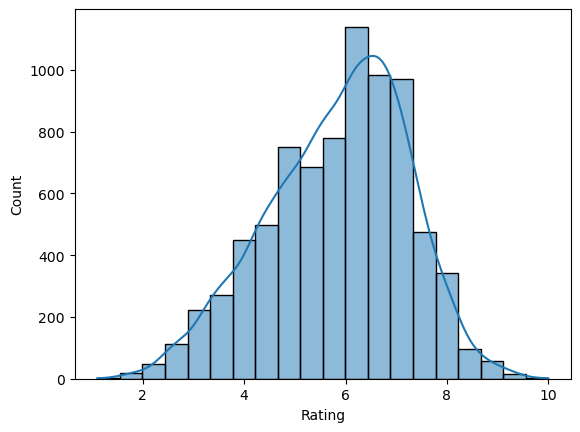

In [23]:
sns.histplot(df['Rating'], bins=20, kde=True)
plt.show()

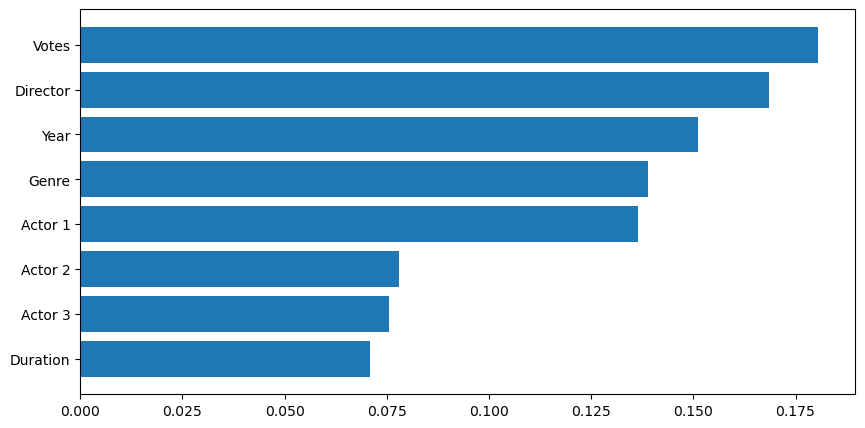

In [24]:
importances = rf.feature_importances_
features = X_train_encoded.columns
indices = np.argsort(importances)

plt.figure(figsize=(10, 5))
plt.barh(range(len(indices)), importances[indices], align='center')
plt.yticks(range(len(indices)), [features[i] for i in indices])
plt.show()